# Generate csv file as input

In [ ]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp

# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

# Number of runs per workload

workload_dir = './workload'

entries = 100000
versions = 10


csv_dir = format("./csv_%dentries_%dversions" % (entries, versions))
print(csv_dir)
os.makedirs(csv_dir, exist_ok=True)

print("Deleted existing CSV files.")
# Clean up old CSV files in workload and csv directories
for f in glob.glob(os.path.join(csv_dir, '*.csv')):
    os.remove(f)

# Run gen_data.py to generate data_multiversion.csv
print("Running gen_data_multiversion.py...")
subprocess.run([
    'python3', './gen_py/gen_data_multiversion.py',
    '-o', os.path.join(csv_dir, 'data_multiversion.csv'),
    '-n', '100000', '-k', '100', '-p', '8', '-vmin', '892', '-vmax', '892', '-s', '500',
    '-vc', '10'
], check=True)
print("data_multiversion.csv generated.")

# Generate workloads (txs and ops files)
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads_get_mv.py',
                '-od', csv_dir,
                ], check=True)
print("Workloads generated.")


./csv
Deleted existing CSV files.
Running gen_data_multiversion.py...
data_multiversion.csv generated.
Generating workloads...
generating get workloads... output dir ./csv
Generated mixed operations in ./csv/hget_ratio000_ops.csv
Generated mixed operations in ./csv/hget_ratio020_ops.csv
Generated mixed operations in ./csv/hget_ratio040_ops.csv
Generated mixed operations in ./csv/hget_ratio060_ops.csv
Generated mixed operations in ./csv/hget_ratio080_ops.csv
Generated mixed operations in ./csv/hget_ratio100_ops.csv
Workloads generated.


# Run benchmark with statistics (Only chain implementation support statistics now)

In [ ]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display, Markdown

# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

entries = 100000
versions = 10

# Number of runs per workload
number_of_runs = 1

workload_dir = './workload'
csv_dir = format("./csv_%dentries_%dversions" % (entries, versions))

# Build the binary to ensure it's up-to-date
print("Building hash_join_bench with cargo build --release...")
myenv = os.environ.copy()
myenv["RUSTFLAGS"] = "-Awarnings"
subprocess.run(['cargo', 'build', '--release', '--bin', 'hash_join_bench_mixed_get'], check=True, env=myenv)
print("Build completed.")

binary = '../../../target/release/hash_join_bench_mixed_get'
data_file = os.path.join(csv_dir, 'data_multiversion.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns, recent_get_ns, history_get_ns}

for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')
    
    # Corresponding recent/history after ops files
    recent_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_recent_data_after_ops.csv')
    history_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_history_data_after_ops.csv')

    # Run the benchmark multiple times for each workload
    for run_id in range(1, number_of_runs+1):
        print(f"Running benchmark for workload {workload_name}, run {run_id}...")
        cmd = [
            binary,
            '-df', data_file,
            '-of', ops_path,
            '-rdf', recent_data_after_ops_file,
            '-hdf', history_data_after_ops_file,
            '-sof', scan_ops_file
        ]

        print("cmd:", cmd)

        completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if completed.returncode != 0:
            print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
            print(completed.stderr)
            continue

        output = completed.stdout
        print("benchmark run output:", output)

        # Extract statistics block (which includes our GET time metrics)
        pattern = r"===STAT_START===\n(.*?)\n===STAT_END==="
        match = re.search(pattern, output, re.DOTALL)
        stat_output = ""
        recent_get_time_ns = None
        history_get_time_ns = None
        if match:
            stat_output = match.group(1)
            print("Extracted Statistics:")
            print(stat_output)
            display(Markdown(f"```\n{stat_output}\n```"))
            # Parse recent and history get times from the statistics output
            for line in stat_output.splitlines():
                if line.startswith("Total time spent in recent_chain.get():"):
                    m = re.search(r"Total time spent in recent_chain\.get\(\): (\d+) ns", line)
                    if m:
                        recent_get_time_ns = int(m.group(1))
                elif line.startswith("Total time spent in history_chain.get():"):
                    m = re.search(r"Total time spent in history_chain\.get\(\): (\d+) ns", line)
                    if m:
                        history_get_time_ns = int(m.group(1))
        else:
            print("Could not find statistics markers in the output.")

        # Parse other times (loading and execution times)
        rust_load_time_ns = None
        hj_load_time_ns = None
        rust_time_ns = None
        hj_execute_time_ns = None

        for line in output.splitlines():
            if line.startswith("Loaded") and "Rust HashMap" in line:
                m = re.search(r'Loaded \d+ entries into Rust HashMap in (\d+) ns', line)
                if m:
                    rust_load_time_ns = int(m.group(1))
            elif line.startswith("Loaded") and "HashJoinTable" in line:
                m = re.search(r'Loaded \d+ entries into HashJoinTable in (\d+) ns', line)
                if m:
                    hj_load_time_ns = int(m.group(1))
            elif line.startswith("Rust HashMap: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    rust_time_ns = int(m.group(1))
            elif line.startswith("HashJoinTable: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    hj_execute_time_ns = int(m.group(1))

        if (rust_time_ns is None or hj_execute_time_ns is None or
            rust_load_time_ns is None or hj_load_time_ns is None):
            print("Warning: Could not parse all times from output for this run:")
            print(output)
        else:
            results.append({
                'workload': workload_name,
                'run': run_id,
                'rust_load_ns': rust_load_time_ns,
                'hj_load_ns': hj_load_time_ns,
                'rust_exec_ns': rust_time_ns,
                'hj_exec_ns': hj_execute_time_ns,
                'recent_get_ns': recent_get_time_ns if recent_get_time_ns is not None else 0,
                'history_get_ns': history_get_time_ns if history_get_time_ns is not None else 0,
            })

print("Benchmarking completed.")
print("results:", results)
df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and standard deviations for each workload
    stats = df.groupby('workload').agg({
        'rust_load_ns': ['mean', 'std'],
        'hj_load_ns': ['mean', 'std'],
        'rust_exec_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std'],
        'recent_get_ns': ['mean', 'std'],
        'history_get_ns': ['mean', 'std']
    })

    # Flatten the MultiIndex columns
    stats.columns = [
        'rust_load_mean', 'rust_load_std',
        'hj_load_mean', 'hj_load_std',
        'rust_exec_mean', 'rust_exec_std',
        'hj_exec_mean', 'hj_exec_std',
        'recent_get_mean', 'recent_get_std',
        'history_get_mean', 'history_get_std'
    ]
    stats = stats.reset_index()
    stats = stats.sort_values('workload')

    # Convert nanoseconds to milliseconds for readability
    stats['rust_load_mean_ms'] = stats['rust_load_mean'] / 1_000_000
    stats['rust_exec_mean_ms'] = stats['rust_exec_mean'] / 1_000_000
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000
    stats['recent_get_mean_ms'] = stats['recent_get_mean'] / 1_000_000
    stats['history_get_mean_ms'] = stats['history_get_mean'] / 1_000_000

    # Print the averaged results
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  Rust HashMap: load={row['rust_load_mean_ms']:.2f} ms, exec={row['rust_exec_mean_ms']:.2f} ms")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")
        print(f"  recent_chain.get(): {row['recent_get_mean_ms']:.2f} ms, history_chain.get(): {row['history_get_mean_ms']:.2f} ms")

    # 1) Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_exec_mean_ms'], yerr=stats['rust_exec_std']/1_000_000, fmt='o-', label='HashTable with SingleChain Exec')
    plt.errorbar(X, stats['hj_exec_mean_ms'], yerr=stats['hj_exec_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Exec')
    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_exec_mean_ms'].iloc[i] + 0.05, f"{stats['rust_exec_mean_ms'].iloc[i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_exec_mean_ms'].iloc[i] + 0.05, f"{stats['hj_exec_mean_ms'].iloc[i]:.2f} ms", ha='center', color='orange')
    plt.tight_layout()
    plt.show()

    # 2) Plot Loading Times Comparison
    plt.figure(figsize=(10,6))
    plt.errorbar(X, stats['rust_load_mean_ms'], yerr=stats['rust_load_std']/1_000_000, fmt='o-', label='HashTable with SingleChain Load')
    plt.errorbar(X, stats['hj_load_mean_ms'], yerr=stats['hj_load_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Load')
    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_load_mean_ms'].iloc[i] + 0.05, f"{stats['rust_load_mean_ms'].iloc[i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_load_mean_ms'].iloc[i] + 0.05, f"{stats['hj_load_mean_ms'].iloc[i]:.2f} ms", ha='center', color='orange')
    plt.tight_layout()
    plt.show()

    # 3) Plot GET Times Comparison (recent vs history)
    plt.figure(figsize=(10,6))
    plt.errorbar(X, stats['recent_get_mean_ms'], yerr=stats['recent_get_std']/1_000_000, fmt='o-', label='recent_chain.get()')
    plt.errorbar(X, stats['history_get_mean_ms'], yerr=stats['history_get_std']/1_000_000, fmt='o-', label='history_chain.get()')
    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Total GET Time (ms)')
    plt.title('Benchmark Comparison (GET Times)')
    plt.legend()
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['recent_get_mean_ms'].iloc[i] + 0.05, f"{stats['recent_get_mean_ms'].iloc[i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['history_get_mean_ms'].iloc[i] + 0.05, f"{stats['history_get_mean_ms'].iloc[i]:.2f} ms", ha='center', color='orange')
    plt.tight_layout()
    plt.show()

    # 4) Plot Execution & GET Times (smaller annotation font)
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_exec_mean_ms'], 
                 yerr=stats['rust_exec_std']/1_000_000, 
                 fmt='o-', 
                 label='HashTable with SingleChain Exec')
    plt.errorbar(X, stats['hj_exec_mean_ms'], 
                 yerr=stats['hj_exec_std']/1_000_000, 
                 fmt='s-', 
                 label='MvccHashJoinTable Exec')
    plt.errorbar(X, stats['recent_get_mean_ms'], 
                 yerr=stats['recent_get_std']/1_000_000, 
                 fmt='^-', 
                 label='recent_chain.get()')
    plt.errorbar(X, stats['history_get_mean_ms'], 
                 yerr=stats['history_get_std']/1_000_000, 
                 fmt='v-', 
                 label='history_chain.get()')
    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Time (ms)')
    plt.title('Benchmark Comparison: Execution & GET Times')
    plt.legend()

    # ---- Annotate data points (smaller font) ----
    for i, x_val in enumerate(X):
        # Rust Exec
        plt.text(
            x_val,
            stats['rust_exec_mean_ms'].iloc[i] + 0.05,
            f"{stats['rust_exec_mean_ms'].iloc[i]:.2f} ms",
            ha='center',
            color='blue',
            fontsize=9
        )
        # MvccHashJoinTable Exec
        plt.text(
            x_val,
            stats['hj_exec_mean_ms'].iloc[i] + 0.05,
            f"{stats['hj_exec_mean_ms'].iloc[i]:.2f} ms",
            ha='center',
            color='green',
            fontsize=9
        )
        # recent_chain.get()
        plt.text(
            x_val,
            stats['recent_get_mean_ms'].iloc[i] + 0.05,
            f"{stats['recent_get_mean_ms'].iloc[i]:.2f} ms",
            ha='center',
            color='red',
            fontsize=9
        )
        # history_chain.get()
        plt.text(
            x_val,
            stats['history_get_mean_ms'].iloc[i] + 0.05,
            f"{stats['history_get_mean_ms'].iloc[i]:.2f} ms",
            ha='center',
            color='orange',
            fontsize=9
        )
    # ---------------------------------------------

    plt.tight_layout()
    plt.show()

    # 5) Plot Execution & GET Times (bigger annotation font)
    plt.figure(figsize=(10,6))
    X = range(len(stats))

    # Plot each series with error bars and custom markers
    plt.errorbar(
        X, stats['rust_exec_mean_ms'], 
        yerr=stats['rust_exec_std']/1_000_000, 
        fmt='o-', 
        label='HashTable with SingleChain Exec',
        capsize=5
    )
    plt.errorbar(
        X, stats['hj_exec_mean_ms'], 
        yerr=stats['hj_exec_std']/1_000_000, 
        fmt='s-', 
        label='MvccHashJoinTable Exec',
        capsize=5
    )
    plt.errorbar(
        X, stats['recent_get_mean_ms'], 
        yerr=stats['recent_get_std']/1_000_000, 
        fmt='^-', 
        label='recent_chain.get()',
        capsize=5
    )
    plt.errorbar(
        X, stats['history_get_mean_ms'], 
        yerr=stats['history_get_std']/1_000_000, 
        fmt='v-', 
        label='history_chain.get()',
        capsize=5
    )

    # Set x-ticks with adjusted font size
    plt.xticks(X, stats['workload'], rotation=45, fontsize=12)
    plt.xlabel('Workload', fontsize=14)
    plt.ylabel('Time (ms)', fontsize=14)
    plt.title('Benchmark Comparison: Execution & GET Times', fontsize=16)
    plt.legend(fontsize=12)

    # Annotate each data point (bigger font)
    for i, x_val in enumerate(X):
        plt.text(
            x_val, stats['rust_exec_mean_ms'].iloc[i] + 0.05, 
            f"{stats['rust_exec_mean_ms'].iloc[i]:.2f} ms", 
            ha='center', color='blue', fontsize=10
        )
        plt.text(
            x_val, stats['hj_exec_mean_ms'].iloc[i] + 0.05, 
            f"{stats['hj_exec_mean_ms'].iloc[i]:.2f} ms", 
            ha='center', color='green', fontsize=10
        )
        plt.text(
            x_val, stats['recent_get_mean_ms'].iloc[i] + 0.05, 
            f"{stats['recent_get_mean_ms'].iloc[i]:.2f} ms", 
            ha='center', color='red', fontsize=10
        )
        plt.text(
            x_val, stats['history_get_mean_ms'].iloc[i] + 0.05, 
            f"{stats['history_get_mean_ms'].iloc[i]:.2f} ms", 
            ha='center', color='orange', fontsize=10
        )

    plt.tight_layout()
    plt.show()


Building hash_join_bench with cargo build --release...
Build completed.
Running benchmark for workload hget_ratio000, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-rdf', './csv/hget_ratio000_recent_data_after_ops.csv', '-hdf', './csv/hget_ratio000_history_data_after_ops.csv', '-sof', './csv/scan_ops.csv']
benchmark run output: Data file: ./csv/data_multiversion.csv
Ops file: ./csv/hget_ratio000_ops.csv

Loaded 100 entries with 10 versions into HashJoinTable in 320356 ns

HashJoinTable: Executed 11000 operations in 5801757 ns

===STAT_START===

Could not find statistics markers in the output.
Data file: ./csv/data_multiversion.csv
Ops file: ./csv/hget_ratio000_ops.csv

Loaded 100 entries with 10 versions into HashJoinTable in 320356 ns

HashJoinTable: Executed 11000 operations in 5801757 ns

===STAT_START===

Running benchmark for workload hget_ratio020, run 1...
cmd: ['../../../target/re

    Finished `release` profile [optimized + debuginfo] target(s) in 0.05s


benchmark run output: Data file: ./csv/data_multiversion.csv
Ops file: ./csv/hget_ratio020_ops.csv

Loaded 100 entries with 10 versions into HashJoinTable in 328873 ns

HashJoinTable: Executed 11000 operations in 5844422 ns

===STAT_START===

Could not find statistics markers in the output.
Data file: ./csv/data_multiversion.csv
Ops file: ./csv/hget_ratio020_ops.csv

Loaded 100 entries with 10 versions into HashJoinTable in 328873 ns

HashJoinTable: Executed 11000 operations in 5844422 ns

===STAT_START===

Running benchmark for workload hget_ratio040, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio040_ops.csv', '-rdf', './csv/hget_ratio040_recent_data_after_ops.csv', '-hdf', './csv/hget_ratio040_history_data_after_ops.csv', '-sof', './csv/scan_ops.csv']
benchmark run output: Data file: ./csv/data_multiversion.csv
Ops file: ./csv/hget_ratio040_ops.csv

Loaded 100 entries with 10 versions into HashJoinTab

# Run benchmark without statistics

csv_dir is ./csv
Building hash_join_bench with cargo build --release...
Build completed.
Running benchmark for workload hget_ratio000, table type chain, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-t', 'chain']


    Finished `release` profile [optimized + debuginfo] target(s) in 0.03s


Running benchmark for workload hget_ratio000, table type open_address, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-t', 'open_address']
Running benchmark for workload hget_ratio000, table type rust, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-t', 'rust']
Running benchmark for workload hget_ratio000, table type heap, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-t', 'heap']
Running benchmark for workload hget_ratio000, table type linear, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-t', 'linear']
Running benchmark for workload hget_ratio020, table type chain, run 1...
cmd: ['../../../target/

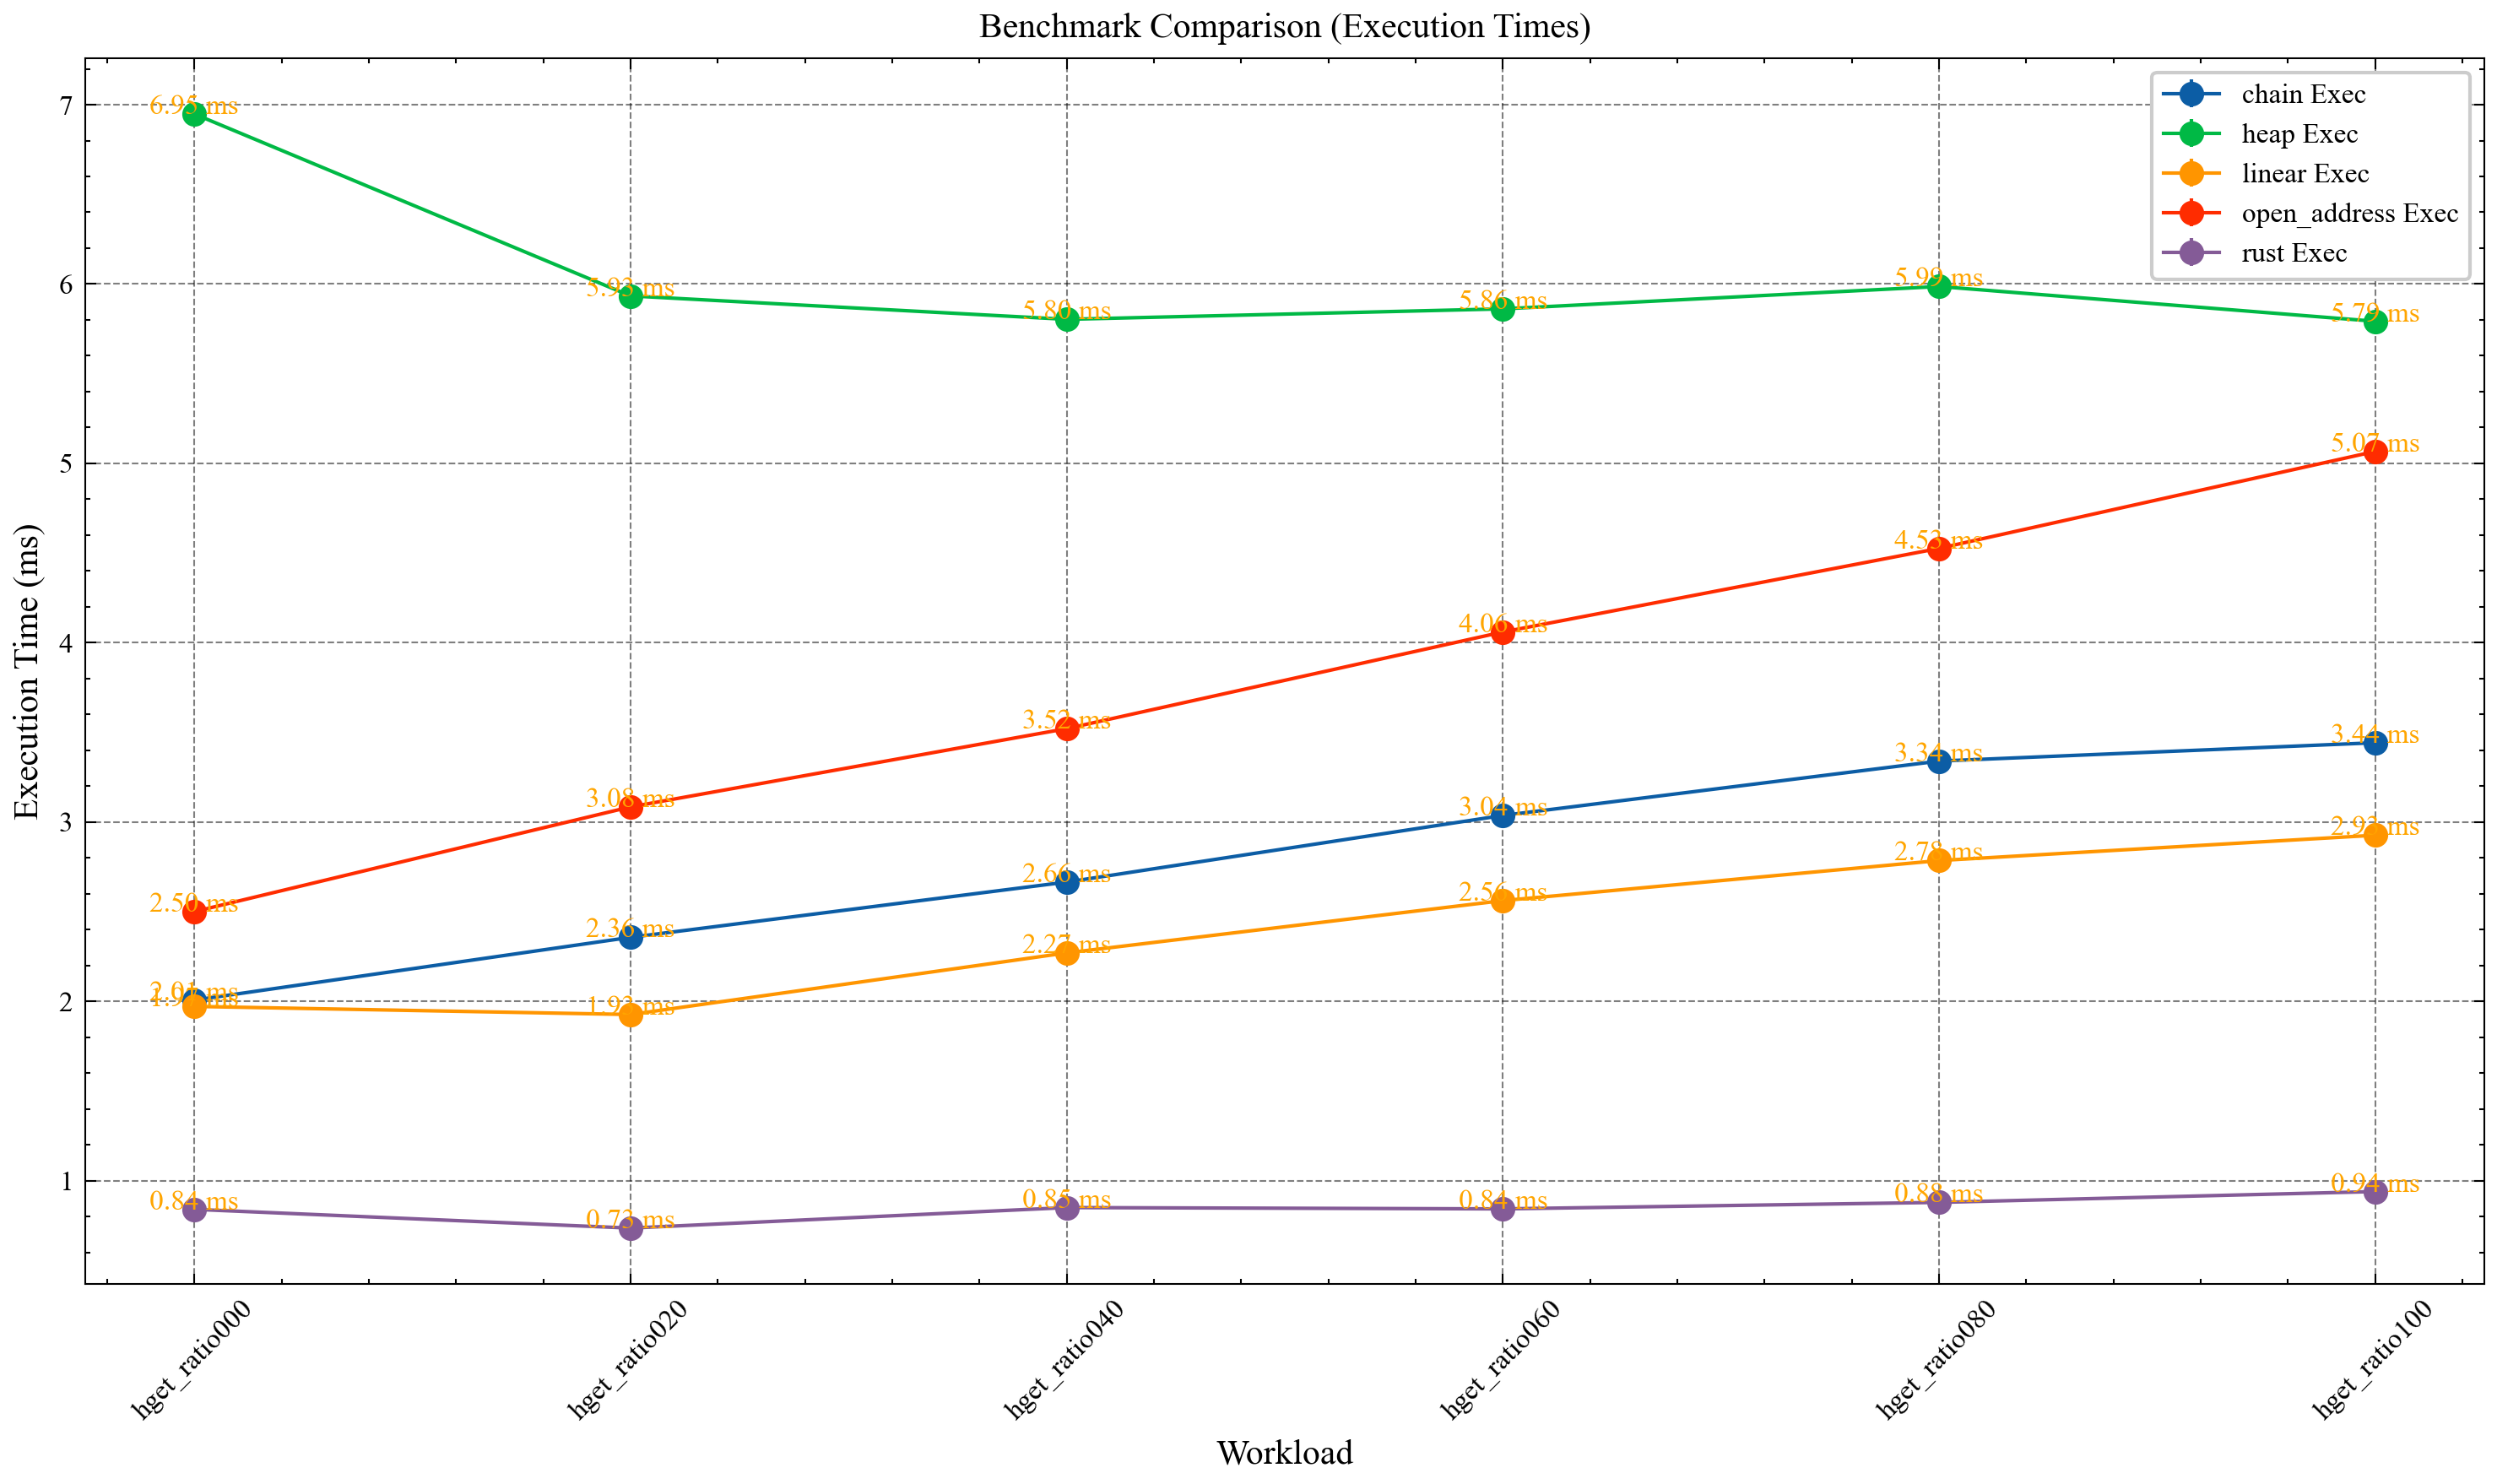

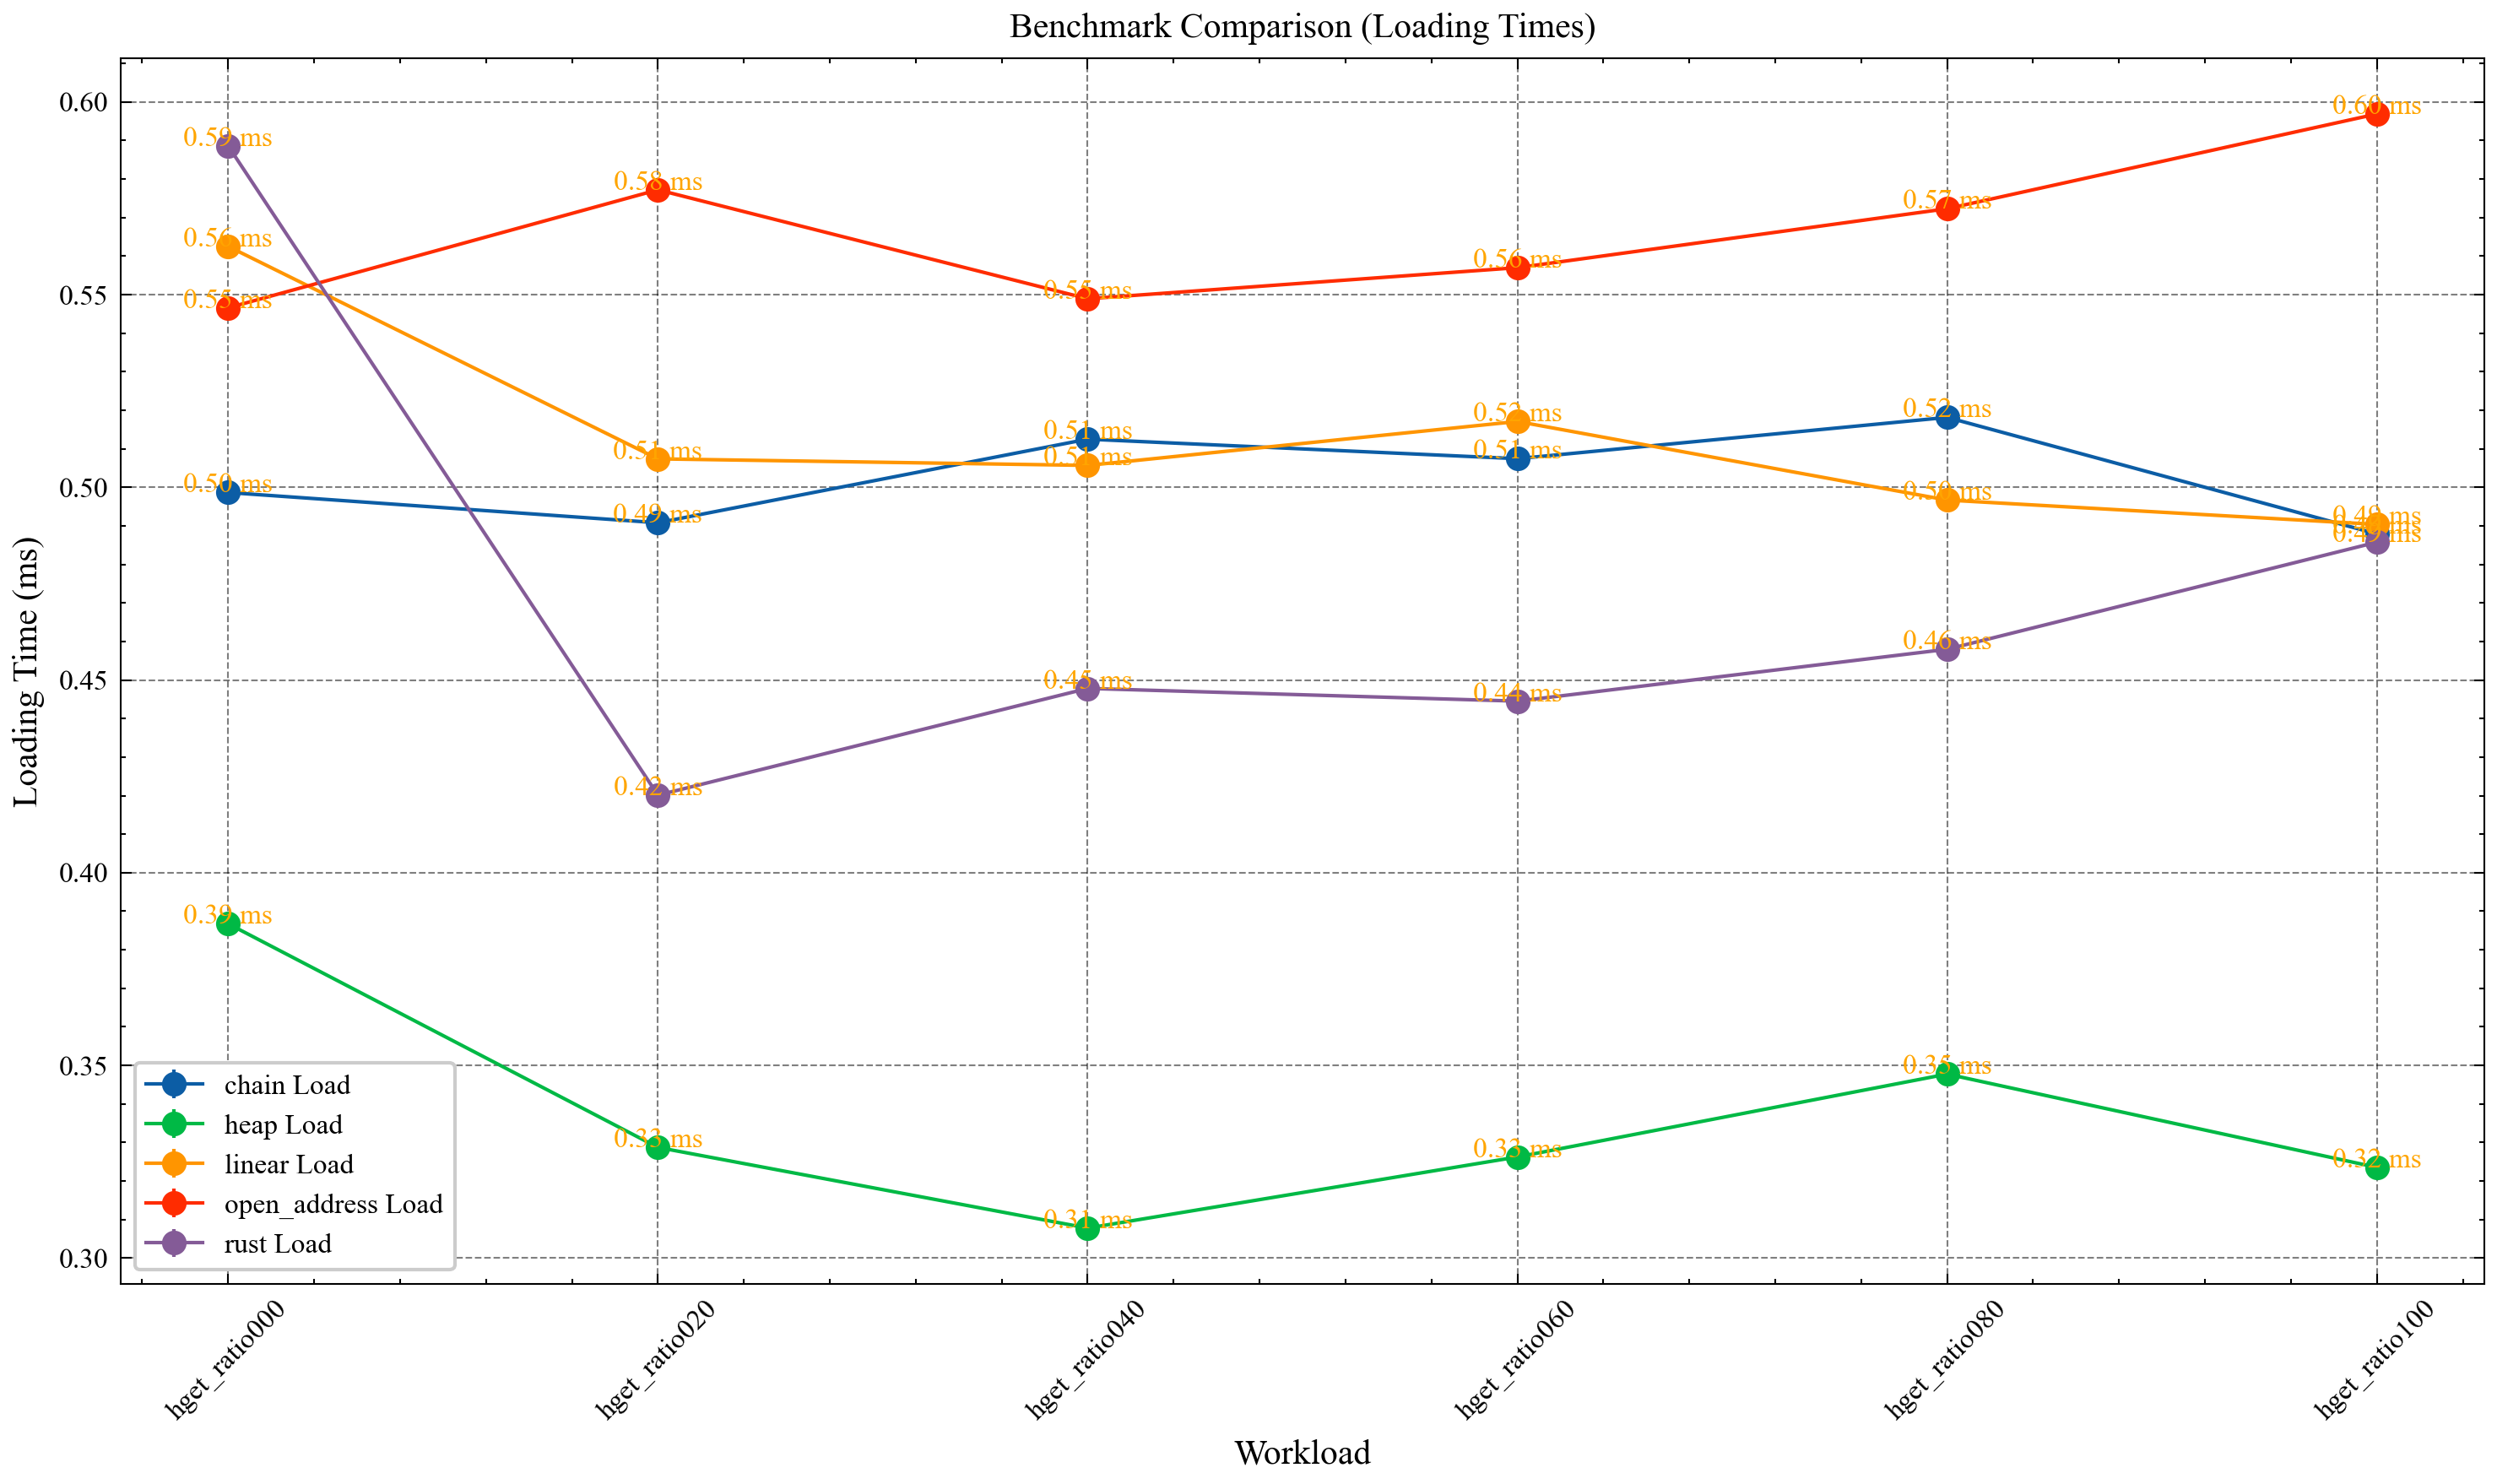

In [ ]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display, Markdown

# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

# Number of runs per workload
number_of_runs = 1
entries= 100000
versions = 10
workload_dir = './workload'
csv_dir = format("./csv_%dentries_%dversions" % (entries, versions))
# csv_dir = "./csv"
print(f"csv_dir is {csv_dir}")
# Build the binary to ensure it's up-to-date
print("Building hash_join_bench with cargo build --release...")
myenv = os.environ.copy()
myenv["RUSTFLAGS"] = "-Awarnings"
subprocess.run(['cargo', 'build', '--release', '--bin', 'hash_join_bench_mixed_get'], check=True, env=myenv)
print("Build completed.")

binary = '../../../target/release/hash_join_bench_mixed_get'
data_file = os.path.join(csv_dir, 'data_multiversion.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns, recent_get_ns, history_get_ns}
hash_join_table_type_list = ['chain', 'open_address', 'rust', 'heap', 'linear']
for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')
    
    for hash_join_table_type in hash_join_table_type_list:
        # Run the benchmark multiple times for each workload
        for run_id in range(1, number_of_runs+1):
            print(f"Running benchmark for workload {workload_name}, table type {hash_join_table_type}, run {run_id}...")
            cmd = [
                binary,
                '-df', data_file,
                '-of', ops_path,
                '-t', hash_join_table_type
            ]

            print("cmd:", cmd)

            completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
            if completed.returncode != 0:
                print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
                print(completed.stderr)
                continue

            output = completed.stdout
            # print("benchmark run output:", output)

            # Parse other times (loading and execution times)
            hj_load_time_ns = None
            hj_execute_time_ns = None

            for line in output.splitlines():
                if line.startswith("Loaded") and "HashJoinTable" in line:
                    m = re.search(r'Loaded (\d+) entries with (\d+) versions into HashJoinTable in (\d+) ns', line)
                    if m:
                        hj_load_time_ns = int(m.group(3))
                elif line.startswith("HashJoinTable: Executed"):
                    m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                    if m:
                        hj_execute_time_ns = int(m.group(1))

            if (hj_execute_time_ns is None or hj_load_time_ns is None):
                print("Warning: Could not parse all times from output for this run:")
                print(output)
            else:
                results.append({
                    'workload': workload_name,
                    'hash_join_table_type': hash_join_table_type,
                    'run': run_id,
                    'hj_load_ns': hj_load_time_ns,
                    'hj_exec_ns': hj_execute_time_ns,
                })

print("Benchmarking completed.")
print("results:", results)
df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and standard deviations for each workload
    stats = df.groupby(['workload', 'hash_join_table_type']).agg({
        'hj_load_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std'],
    })

    # Flatten the MultiIndex columns
    stats.columns = [
        'hj_load_mean', 'hj_load_std',
        'hj_exec_mean', 'hj_exec_std',
    ]
    stats = stats.reset_index()
    stats = stats.sort_values('workload')

    # Convert nanoseconds to milliseconds for readability
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print the averaged results
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # 1) Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    bar_width = 0.2
    workloads = stats['workload'].unique()
    X = range(len(workloads))

    for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
        plt.errorbar(X, group['hj_exec_mean_ms'], yerr=group['hj_exec_std']/1_000_000, fmt='o-', label=f'{hash_join_table_type} Exec')

    plt.xticks(X, workloads, rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    for i, workload in enumerate(workloads):
        for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
            y_val = group[group['workload'] == workload]['hj_exec_mean_ms'].values[0]
            plt.text(i, y_val + 0.05, f"{y_val:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()

    # 2) Plot Loading Times Comparison
    plt.figure(figsize=(10,6))

    for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
        plt.errorbar(X, group['hj_load_mean_ms'], yerr=group['hj_load_std']/1_000_000, fmt='o-', label=f'{hash_join_table_type} Load')

    plt.xticks(X, workloads, rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()

    for i, workload in enumerate(workloads):
        for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
            y_val = group[group['workload'] == workload]['hj_load_mean_ms'].values[0]
            plt.text(i, y_val + 0.05, f"{y_val:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()



# if plot has outlier, use "y_limit" to cut plot, so that the plot is more readable

Averaged Results:
Workload: hget_ratio000
  MvccHashJoinTable: load=3062.91 ms, exec=13.83 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=1710.34 ms, exec=11647.84 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=1278.98 ms, exec=42.36 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=1514.27 ms, exec=107.06 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=3678.67 ms, exec=56.34 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=2182.04 ms, exec=12878.71 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=2327.23 ms, exec=31.84 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=1541.73 ms, exec=106.73 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=1233.72 ms, exec=26.84 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=1479.75 ms, exec=108.34 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=2636.15 ms, exec=75.37 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=2067.99 ms, exec=11364.06 ms
Workload: hget_ratio060
  MvccHashJoinTable: load=2502.67 

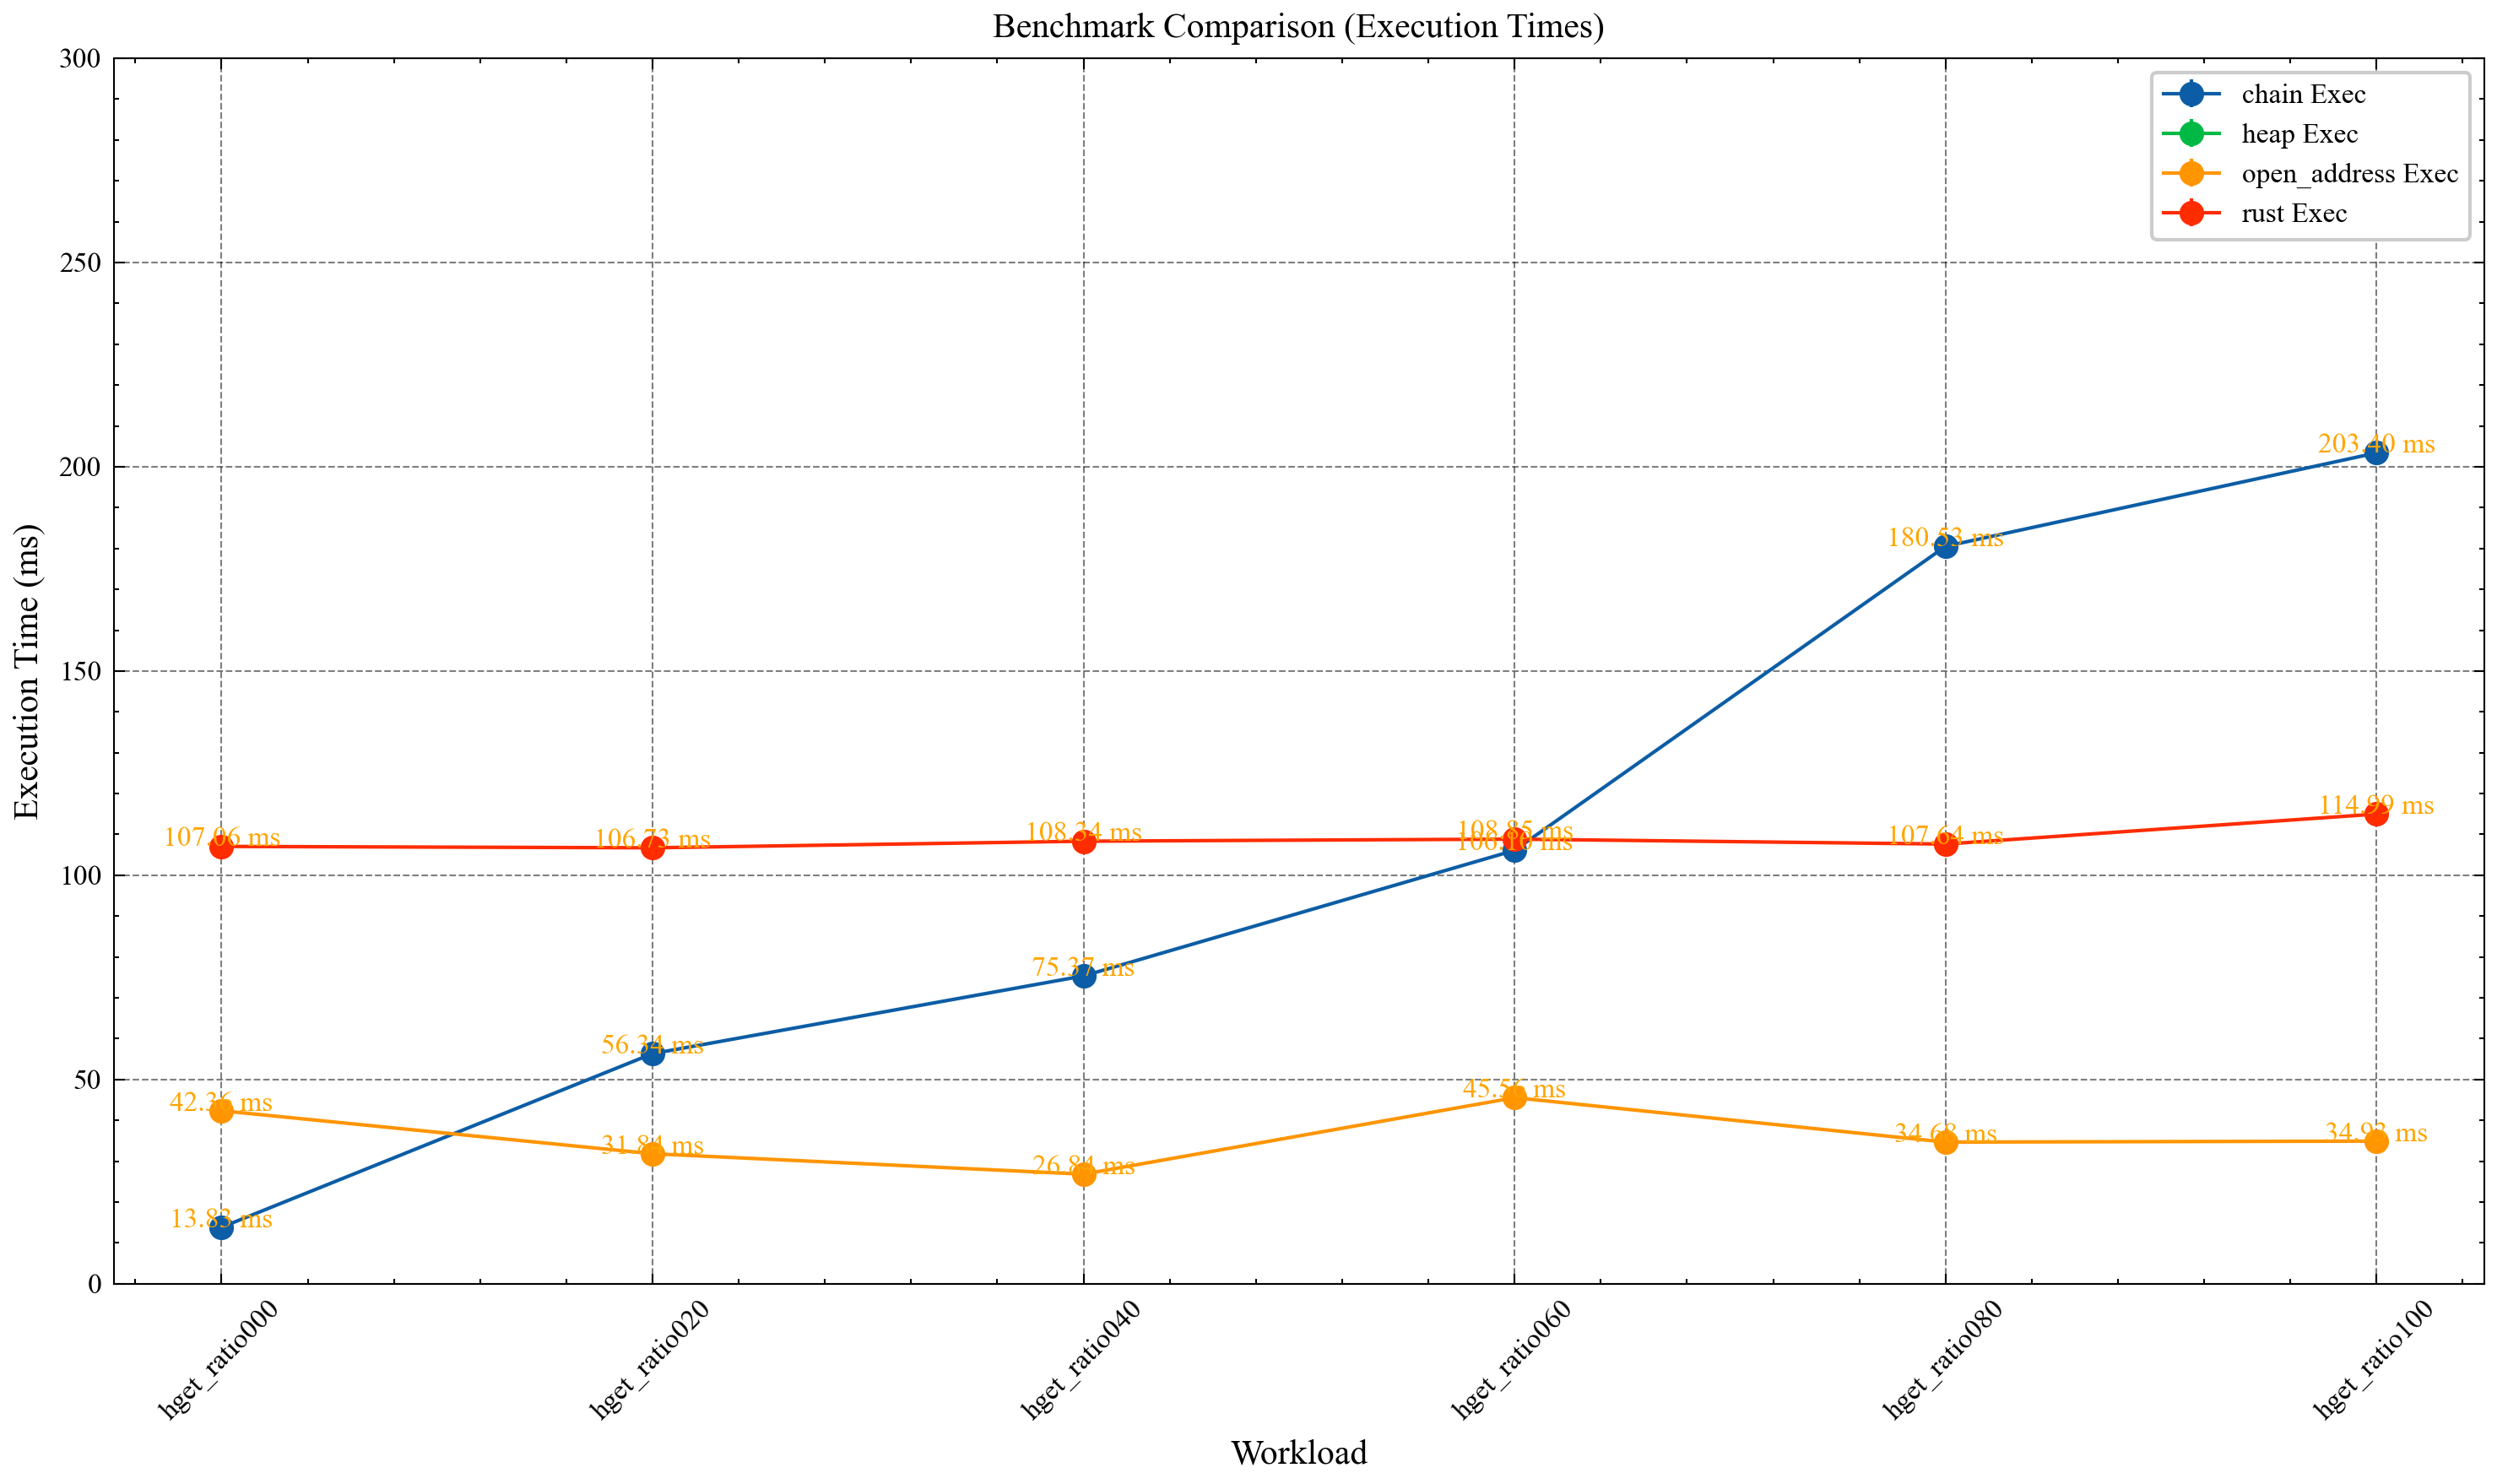

In [6]:
 # Compute means and standard deviations for each workload
stats = df.groupby(['workload', 'hash_join_table_type']).agg({
    'hj_load_ns': ['mean', 'std'],
    'hj_exec_ns': ['mean', 'std'],
})

# Flatten the MultiIndex columns
stats.columns = [
    'hj_load_mean', 'hj_load_std',
    'hj_exec_mean', 'hj_exec_std',
]
stats = stats.reset_index()
stats = stats.sort_values('workload')

# Convert nanoseconds to milliseconds for readability
stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

# Print the averaged results
print("Averaged Results:")
for i, row in stats.iterrows():
    print(f"Workload: {row['workload']}")
    print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

# 1) Plot Execution Times Comparison

plt.figure(figsize=(10,6))
y_limit = 300
plt.ylim(0, y_limit)
bar_width = 0.2
workloads = stats['workload'].unique()
X = range(len(workloads))

for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
    plt.errorbar(X, group['hj_exec_mean_ms'], yerr=group['hj_exec_std']/1_000_000, fmt='o-', label=f'{hash_join_table_type} Exec')

plt.xticks(X, workloads, rotation=45)
plt.xlabel('Workload')
plt.ylabel('Execution Time (ms)')
plt.title('Benchmark Comparison (Execution Times)')
plt.legend()

for i, workload in enumerate(workloads):
    for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
        y_val = group[group['workload'] == workload]['hj_exec_mean_ms'].values[0]
        if y_val < y_limit:
            plt.text(i, y_val + 0.05, f"{y_val:.2f} ms", ha='center', color='orange')

plt.tight_layout()
plt.show()

In [ ]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display, Markdown

# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

# Number of runs per workload
number_of_runs = 1
entries= 10000
versions = 100
workload_dir = './workload'
csv_dir = format("./csv_%dentries_%dversions" % (entries, versions))
print(f"csv_dir is {csv_dir}")
# Build the binary to ensure it's up-to-date
print("Building hash_join_bench with cargo build --release...")
myenv = os.environ.copy()
myenv["RUSTFLAGS"] = "-Awarnings"
subprocess.run(['cargo', 'build', '--release', '--bin', 'hash_join_bench_mixed_get'], check=True, env=myenv)
print("Build completed.")

binary = '../../../target/release/hash_join_bench_mixed_get'
data_file = os.path.join(csv_dir, 'data_multiversion.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns, recent_get_ns, history_get_ns}
hash_join_table_type_list = ['chain', 'open_address', 'rust', 'heap', 'linear']
for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')
    
    for hash_join_table_type in hash_join_table_type_list:
        # Run the benchmark multiple times for each workload
        for run_id in range(1, number_of_runs+1):
            print(f"Running benchmark for workload {workload_name}, table type {hash_join_table_type}, run {run_id}...")
            cmd = [
                binary,
                '-df', data_file,
                '-of', ops_path,
                '-t', hash_join_table_type
            ]

            print("cmd:", cmd)

            completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
            if completed.returncode != 0:
                print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
                print(completed.stderr)
                continue

            output = completed.stdout
            # print("benchmark run output:", output)

            # Parse other times (loading and execution times)
            hj_load_time_ns = None
            hj_execute_time_ns = None

            for line in output.splitlines():
                if line.startswith("Loaded") and "HashJoinTable" in line:
                    m = re.search(r'Loaded (\d+) entries with (\d+) versions into HashJoinTable in (\d+) ns', line)
                    if m:
                        hj_load_time_ns = int(m.group(3))
                elif line.startswith("HashJoinTable: Executed"):
                    m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                    if m:
                        hj_execute_time_ns = int(m.group(1))

            if (hj_execute_time_ns is None or hj_load_time_ns is None):
                print("Warning: Could not parse all times from output for this run:")
                print(output)
            else:
                results.append({
                    'workload': workload_name,
                    'hash_join_table_type': hash_join_table_type,
                    'run': run_id,
                    'hj_load_ns': hj_load_time_ns,
                    'hj_exec_ns': hj_execute_time_ns,
                })

print("Benchmarking completed.")
print("results:", results)
df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and standard deviations for each workload
    stats = df.groupby(['workload', 'hash_join_table_type']).agg({
        'hj_load_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std'],
    })

    # Flatten the MultiIndex columns
    stats.columns = [
        'hj_load_mean', 'hj_load_std',
        'hj_exec_mean', 'hj_exec_std',
    ]
    stats = stats.reset_index()
    stats = stats.sort_values('workload')

    # Convert nanoseconds to milliseconds for readability
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print the averaged results
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # 1) Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    bar_width = 0.2
    workloads = stats['workload'].unique()
    X = range(len(workloads))

    for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
        plt.errorbar(X, group['hj_exec_mean_ms'], yerr=group['hj_exec_std']/1_000_000, fmt='o-', label=f'{hash_join_table_type} Exec')

    plt.xticks(X, workloads, rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    for i, workload in enumerate(workloads):
        for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
            y_val = group[group['workload'] == workload]['hj_exec_mean_ms'].values[0]
            plt.text(i, y_val + 0.05, f"{y_val:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()

    # 2) Plot Loading Times Comparison
    plt.figure(figsize=(10,6))

    for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
        plt.errorbar(X, group['hj_load_mean_ms'], yerr=group['hj_load_std']/1_000_000, fmt='o-', label=f'{hash_join_table_type} Load')

    plt.xticks(X, workloads, rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()

    for i, workload in enumerate(workloads):
        for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
            y_val = group[group['workload'] == workload]['hj_load_mean_ms'].values[0]
            plt.text(i, y_val + 0.05, f"{y_val:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()


csv_dir is ./csv_10000entries_100versions
Building hash_join_bench with cargo build --release...
Build completed.
Benchmarking completed.
results: []
No results were parsed. Check the output format or regex patterns.


    Finished `release` profile [optimized + debuginfo] target(s) in 0.05s


Averaged Results:
Workload: hget_ratio000
  MvccHashJoinTable: load=0.50 ms, exec=2.01 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=0.39 ms, exec=6.95 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=0.56 ms, exec=1.97 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=0.55 ms, exec=2.50 ms
Workload: hget_ratio000
  MvccHashJoinTable: load=0.59 ms, exec=0.84 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=0.49 ms, exec=2.36 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=0.33 ms, exec=5.93 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=0.51 ms, exec=1.93 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=0.58 ms, exec=3.08 ms
Workload: hget_ratio020
  MvccHashJoinTable: load=0.42 ms, exec=0.73 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=0.55 ms, exec=3.52 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=0.51 ms, exec=2.27 ms
Workload: hget_ratio040
  MvccHashJoinTable: load=0.45 ms, exec=0.85 ms
Workload: hget_ratio040
  MvccHashJoinTable: l

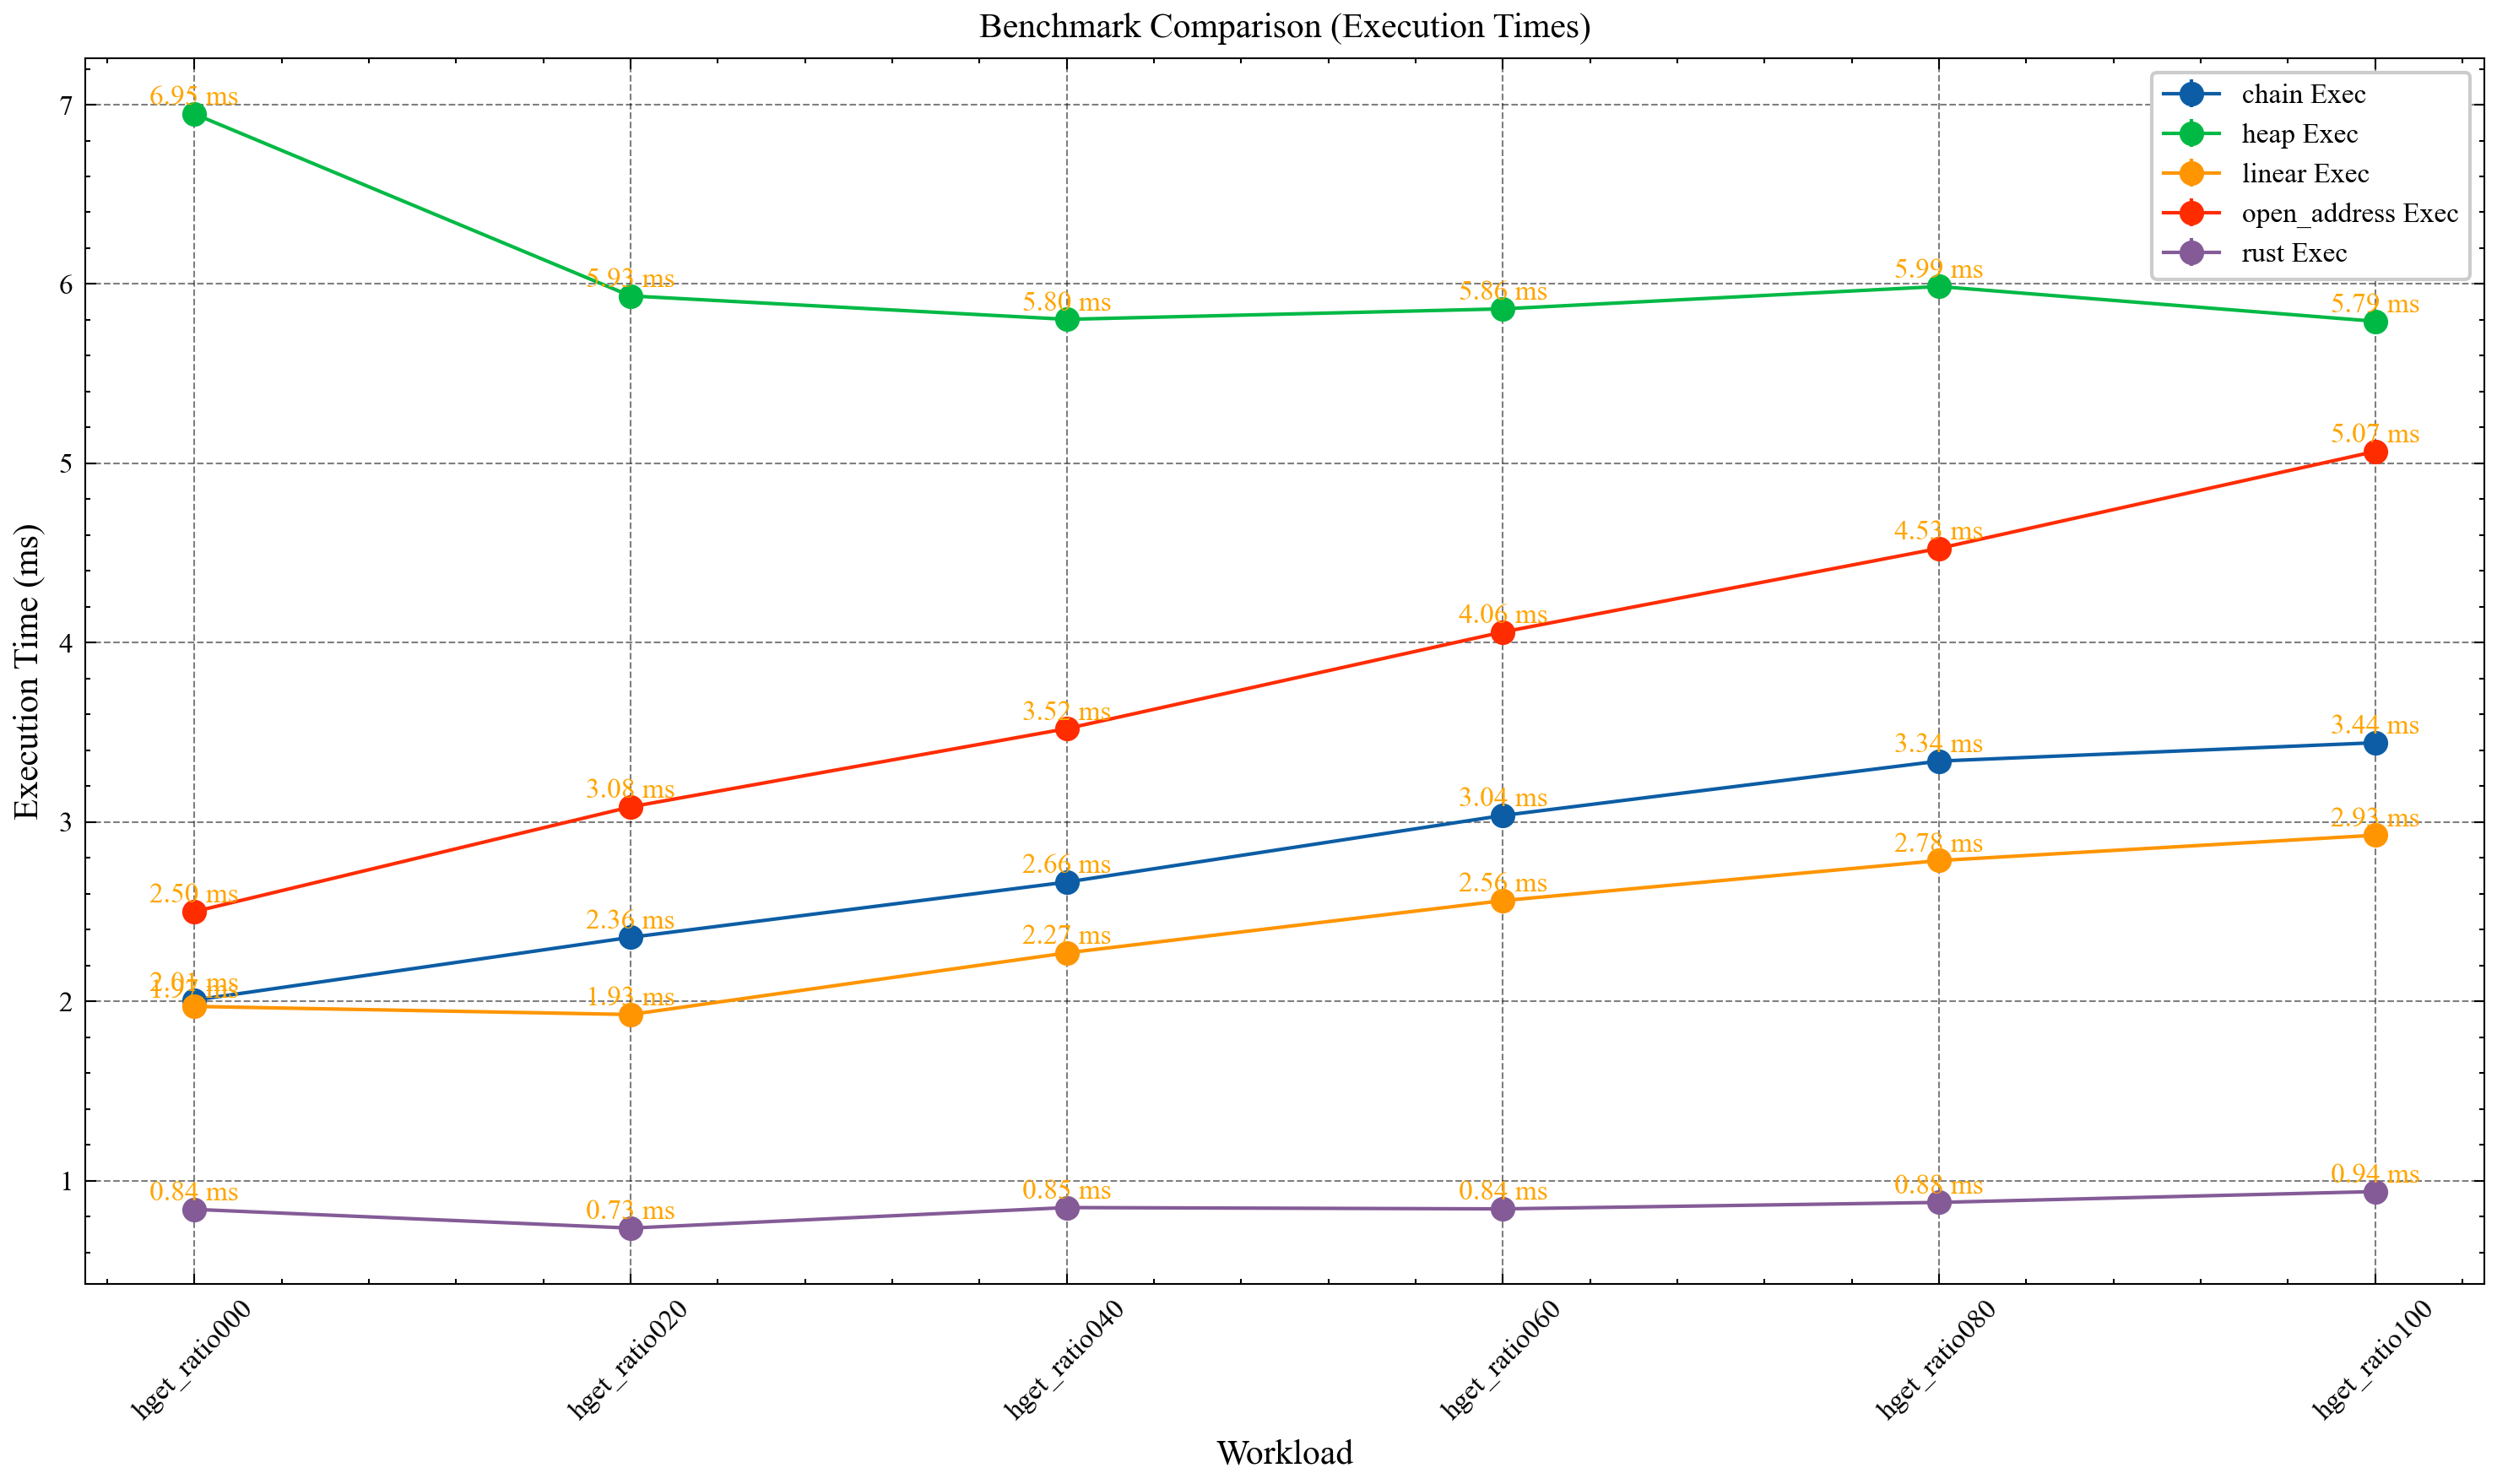

In [10]:
 # Compute means and standard deviations for each workload
stats = df.groupby(['workload', 'hash_join_table_type']).agg({
    'hj_load_ns': ['mean', 'std'],
    'hj_exec_ns': ['mean', 'std'],
})

# Flatten the MultiIndex columns
stats.columns = [
    'hj_load_mean', 'hj_load_std',
    'hj_exec_mean', 'hj_exec_std',
]
stats = stats.reset_index()
stats = stats.sort_values('workload')

# Convert nanoseconds to milliseconds for readability
stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

# Print the averaged results
print("Averaged Results:")
for i, row in stats.iterrows():
    print(f"Workload: {row['workload']}")
    print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

# 1) Plot Execution Times Comparison

plt.figure(figsize=(10,6))
y_limit = 3000
# plt.ylim(0, y_limit)
bar_width = 0.2
workloads = stats['workload'].unique()
X = range(len(workloads))

for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
    plt.errorbar(X, group['hj_exec_mean_ms'], yerr=group['hj_exec_std']/1_000_000, fmt='o-', label=f'{hash_join_table_type} Exec')

plt.xticks(X, workloads, rotation=45)
plt.xlabel('Workload')
plt.ylabel('Execution Time (ms)')
plt.title('Benchmark Comparison (Execution Times)')
plt.legend()

for i, workload in enumerate(workloads):
    for hash_join_table_type, group in stats.groupby('hash_join_table_type'):
        y_val = group[group['workload'] == workload]['hj_exec_mean_ms'].values[0]
        if y_val < y_limit:
            plt.text(i, y_val + 0.05, f"{y_val:.2f} ms", ha='center', color='orange')

plt.tight_layout()
plt.show()